<a href="https://colab.research.google.com/github/umanahekeobong-cell/Fresh-Apple-vs-Formalin-mixed-Apple/blob/main/24_EG_EE_317_L10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

# Specify the path to your zipped file
zipped_file_path = '/content/drive/MyDrive/apple1.zip'  # Replace with your file path

# Specify the directory where you want to extract the contents
extraction_directory = './extracted_applecontent/' # Replace or confirm your desired directory

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_directory, exist_ok=True)

try:
    with zipfile.ZipFile(zipped_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_directory)
    print(f"Successfully unzipped '{zipped_file_path}' to '{extraction_directory}'")
except FileNotFoundError:
    print(f"Error: The file '{zipped_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zipped_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
!pip show matplotlib seaborn scikit-learn tensorflow

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

In [ ]:
results_dir = "results/lab7/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [ ]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')

In [ ]:
import os
import shutil
from pathlib import Path

base_input = "/content/extracted_applecontent/Apple" # Updated path to point to the extracted dataset
base_output = "/content/datasets/applerenamed/" # Changed to an absolute path
base_path = Path(base_output)
base_path

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define split ratios (using global variables if available, or define locally)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Ensure output base directories for splits exist
output_train_dir = os.path.join(base_output, 'train')
output_val_dir = os.path.join(base_output, 'val')
output_test_dir = os.path.join(base_output, 'test')

# --- Clear existing output directories before populating ---
# This ensures a clean slate for each run of the splitting process
if os.path.exists(output_train_dir):
    shutil.rmtree(output_train_dir)
if os.path.exists(output_val_dir):
    shutil.rmtree(output_val_dir)
if os.path.exists(output_test_dir):
    shutil.rmtree(output_test_dir)

os.makedirs(output_train_dir, exist_ok=True)
os.makedirs(output_val_dir, exist_ok=True)
os.makedirs(output_test_dir, exist_ok=True)

# Determine the 'plant' name from the base_input path, e.g., 'Apple'
# rstrip for robustness with trailing slashes
plant_name = os.path.basename(base_input.rstrip('/'))

# Iterate through disease categories within the base_input (e.g., 'Formalin-mixed', 'Fresh', 'Rotten')
for disease_category in os.listdir(base_input):
    # Skip 'Rotten' category as per user request
    if disease_category == 'Rotten':
        print(f"Skipping 'Rotten' category as requested.")
        continue

    current_disease_path = os.path.join(base_input, disease_category)

    # Skip if it's not a directory or a system file like desktop.ini
    if not os.path.isdir(current_disease_path) or disease_category.startswith('.'):
        continue

    # Get all image file paths in the current disease category
    all_files = [os.path.join(current_disease_path, f) for f in os.listdir(current_disease_path)
                 if os.path.isfile(os.path.join(current_disease_path, f)) and not f.startswith('.')]

    if not all_files:
        print(f"No files found in {current_disease_path}. Skipping.")
        continue

    # Create the combined class name for the output directories (e.g., 'Apple_Formalin-mixed')
    class_name = f"{plant_name}_{disease_category}"

    # First split: train and temporary (val + test)
    train_files, temp_files = train_test_split(all_files, train_size=train_ratio, random_state=SEED, shuffle=True)

    # Second split: validate and test from temporary files
    # Calculate adjusted test_size for the second split: test_ratio / (val_ratio + test_ratio)
    # This ensures the ratios are applied correctly to the remaining data
    adjusted_test_size = test_ratio / (val_ratio + test_ratio)
    val_files, test_files = train_test_split(temp_files, test_size=adjusted_test_size, random_state=SEED, shuffle=True)

    # Create destination directories for the current class within each split
    dst_train_class_dir = os.path.join(output_train_dir, class_name)
    dst_val_class_dir = os.path.join(output_val_dir, class_name)
    dst_test_class_dir = os.path.join(output_test_dir, class_name)

    os.makedirs(dst_train_class_dir, exist_ok=True)
    os.makedirs(dst_val_class_dir, exist_ok=True)
    os.makedirs(dst_test_class_dir, exist_ok=True)

    # Copy files to their respective split directories
    for file_path in train_files:
        shutil.copy(file_path, dst_train_class_dir)
    for file_path in val_files:
        shutil.copy(file_path, dst_val_class_dir)
    for file_path in test_files:
        shutil.copy(file_path, dst_test_class_dir)

    print(f"Processed '{class_name}': Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)} files.")

print("Data splitting and copying complete!")

In [ ]:
from pathlib import Path

BASE_DIR = Path(base_output)
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

print(f"Base directory: {BASE_DIR}")
print(f"Train directory: {train_dir}")
print(f"Validation directory: {val_dir}")
print(f"Test directory: {test_dir}")

In [ ]:
for split, d in [('train', train_dir), ('val', val_dir), ('test',
test_dir)]:
    exists = d.exists()
    count = sum(1 for _ in d.rglob('*.jpg')) + sum(1 for _ in
            d.rglob('*.png')) if exists else 0
print(f'{split:>5} dir exists={exists} images≈{count}')

In [ ]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50 # EarlyStopping will stop earlier when converged
LR = 1e-3 # Initial learning rate for the CNN from scratch
print(f'Image size : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learning rate: {LR}')

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
train_dir,image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE,seed=SEED, shuffle=True,
)

In [ ]:
import tensorflow as tf

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
    # Setting shuffle=False for validation and test datasets is often preferred for reproducibility
)

print(f"Validation dataset loaded from: {val_dir}")
print(f"Validation dataset class names: {val_dataset.class_names}")

In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED,shuffle=False,
)

In [ ]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

In [ ]:
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle('Apple Dataset — Sample Images', fontsize=13, fontweight='bold') # Changed title to be more relevant
plt.tight_layout()
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (
train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

In [ ]:
data_augmentation = tf.keras.Sequential([
tf.keras.layers.RandomFlip('horizontal'),
tf.keras.layers.RandomRotation(0.2),
tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

In [ ]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] # shape (1, 224, 224, 3)
    break
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 8):
    aug_img = data_augmentation(sample,
                              training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,
             linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,
             linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_dir + f'lab8_{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model',
                 results_dir='./'):
    """Evaluate a multiclass classification model."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 9, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(
        results_dir + f'lab8_{title.lower().replace(" ", "_")}_confusion.png',
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')

In [ ]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes
def build_custom_cnn(input_shape, augmentation):
    """
    A three-block CNN built entirely from scratch.
    Filters double each block (32 >> 64 >> 128) following a standard design
    pattern.
    Augmentation is embedded inside the model so it runs automatically during
    training.
    """
    inputs = tf.keras.Input(shape=input_shape)
    # Augmentation (active only during training)
    x = augmentation(inputs)
    # Normalise pixel values from [0, 255] to [0, 1]
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    # Binary output: sigmoid → probability of class 1 (dogs)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

In [ ]:
cnn_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [23]:
cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset,epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.6142 - loss: 0.7095 - val_accuracy: 0.4550 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - accuracy: 0.6751 - loss: 0.5776 - val_accuracy: 0.4550 - val_loss: 0.9421 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.7005 - loss: 0.5372 - val_accuracy: 0.4550 - val_loss: 1.0878 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.7401 - loss: 0.5037 - val_accuracy: 0.4550 - val_loss: 1.4695 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.7167 - loss: 0.5036
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.7320 - loss: 0.4956 - val_accuracy: 0.4550 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.7624 - loss: 0.4553 -

In [24]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.7174
val_accuracy: 0.4550


In [25]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.7174
val_accuracy: 0.4550


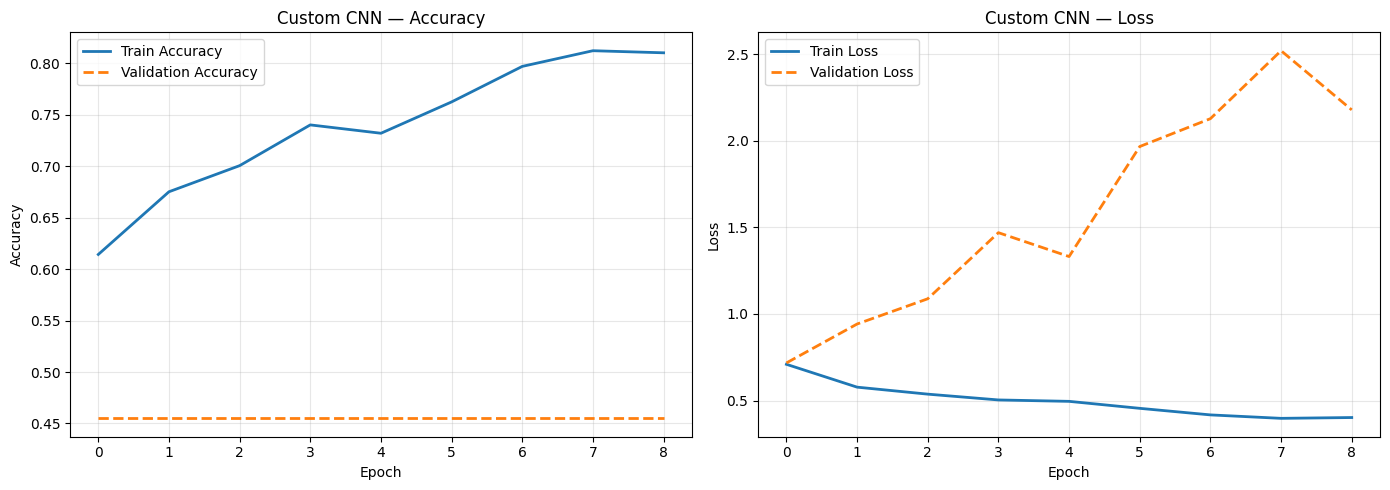

In [26]:
plot_learning_curves(cnn_history, 'Custom CNN')


Custom CNN
Accuracy : 0.4575
Precision : 0.2093
Recall : 0.4575
F1-Score : 0.2873

Classification Report:
                      precision    recall  f1-score   support

Apple_Formalin-mixed     0.4575    1.0000    0.6278        97
         Apple_Fresh     0.0000    0.0000    0.0000       115

            accuracy                         0.4575       212
           macro avg     0.2288    0.5000    0.3139       212
        weighted avg     0.2093    0.4575    0.2873       212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

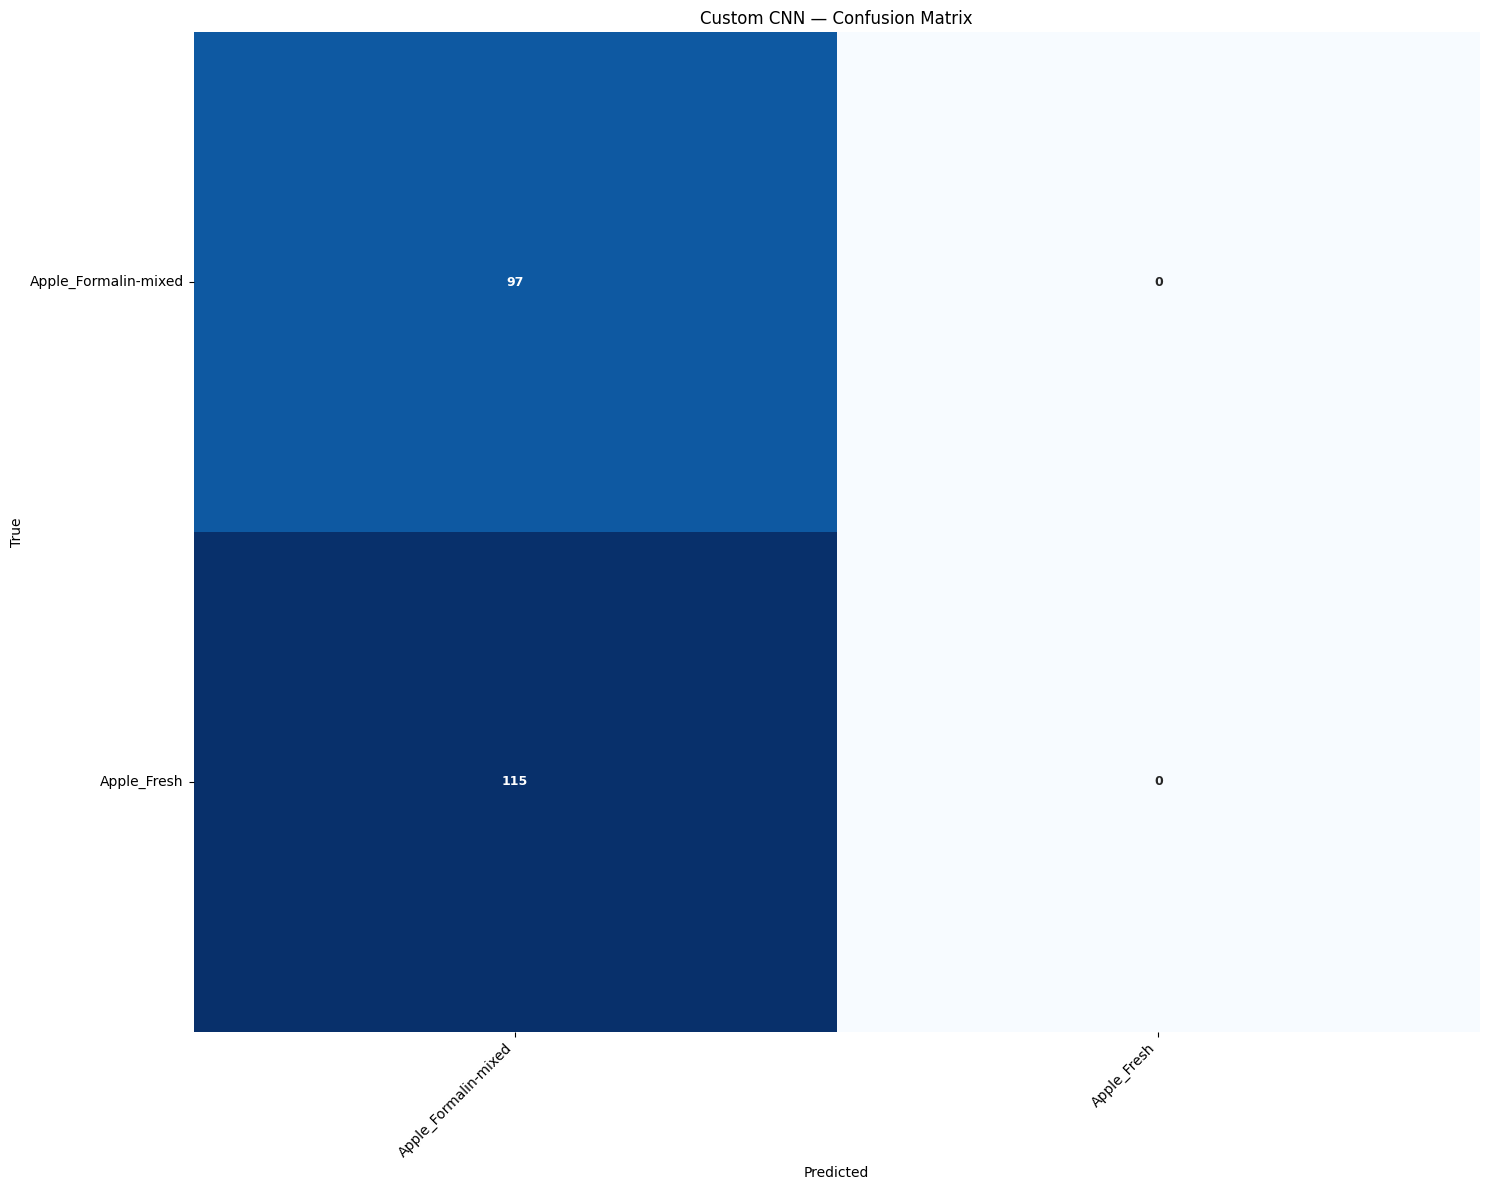

In [27]:
cnn_test_acc = evaluate_model(cnn_model, test_dataset,
class_names, 'Custom CNN')

In [28]:
def build_transfer_model(input_shape, augmentation,
                         backbone='mobilenetv3small'):
    """
    Feature extraction model:
    1. Augment input (training only)
    2. Preprocess for MobileNetV3 (scales to [-1, 1])
    3. Frozen MobileNetV3Small backbone (no top)
    4. GlobalAveragePooling2D
    5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False

    print(f'Base model : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if \
                                  l.trainable)} / {len(base_model.layers)}')

    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]
    x = base_model(x, training=False) # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation,
                                            backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [29]:
TL_LR = 1e-4 # Lower LR for transfer learning head
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
tl_history = tl_model.fit(
train_dataset,
validation_data=val_dataset,
epochs=EPOCHS,
callbacks=make_callbacks('tl_feature_extraction'),
verbose=1,
)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - accuracy: 0.4792 - loss: 0.8062 - val_accuracy: 0.5687 - val_loss: 0.6894 - learning_rate: 1.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5320 - loss: 0.7326 - val_accuracy: 0.6351 - val_loss: 0.6415 - learning_rate: 1.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5675 - loss: 0.6875 - val_accuracy: 0.6872 - val_loss: 0.6076 - learning_rate: 1.0000e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6325 - loss: 0.6461 - val_accuracy: 0.7014 - val_loss: 0.5818 - learning_rate: 1.0000e-04
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6548 - loss: 0.6196 - val_accuracy: 0.7346 - val_loss: 0.5626 - learning_rate: 1.0000e-04
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6558 - loss: 0.5943 - val_accuracy: 0.7251 - val_loss: 0.5474 - learning_rate: 1.0000e-04
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.696

MobileNetV3 TL -> val_loss: 0.4380
MobileNetV3 TL -> val_accuracy: 0.7773


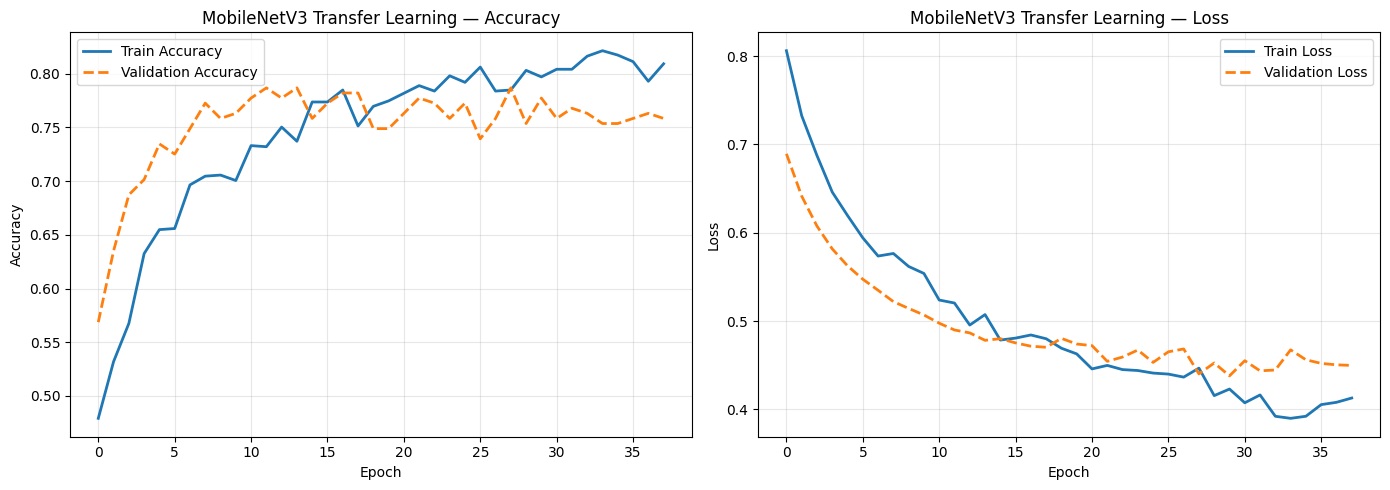

In [30]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')


MobileNetV3 Transfer
Accuracy : 0.7877
Precision : 0.7942
Recall : 0.7877
F1-Score : 0.7843

Classification Report:
                      precision    recall  f1-score   support

Apple_Formalin-mixed     0.8333    0.6701    0.7429        97
         Apple_Fresh     0.7612    0.8870    0.8193       115

            accuracy                         0.7877       212
           macro avg     0.7973    0.7785    0.7811       212
        weighted avg     0.7942    0.7877    0.7843       212



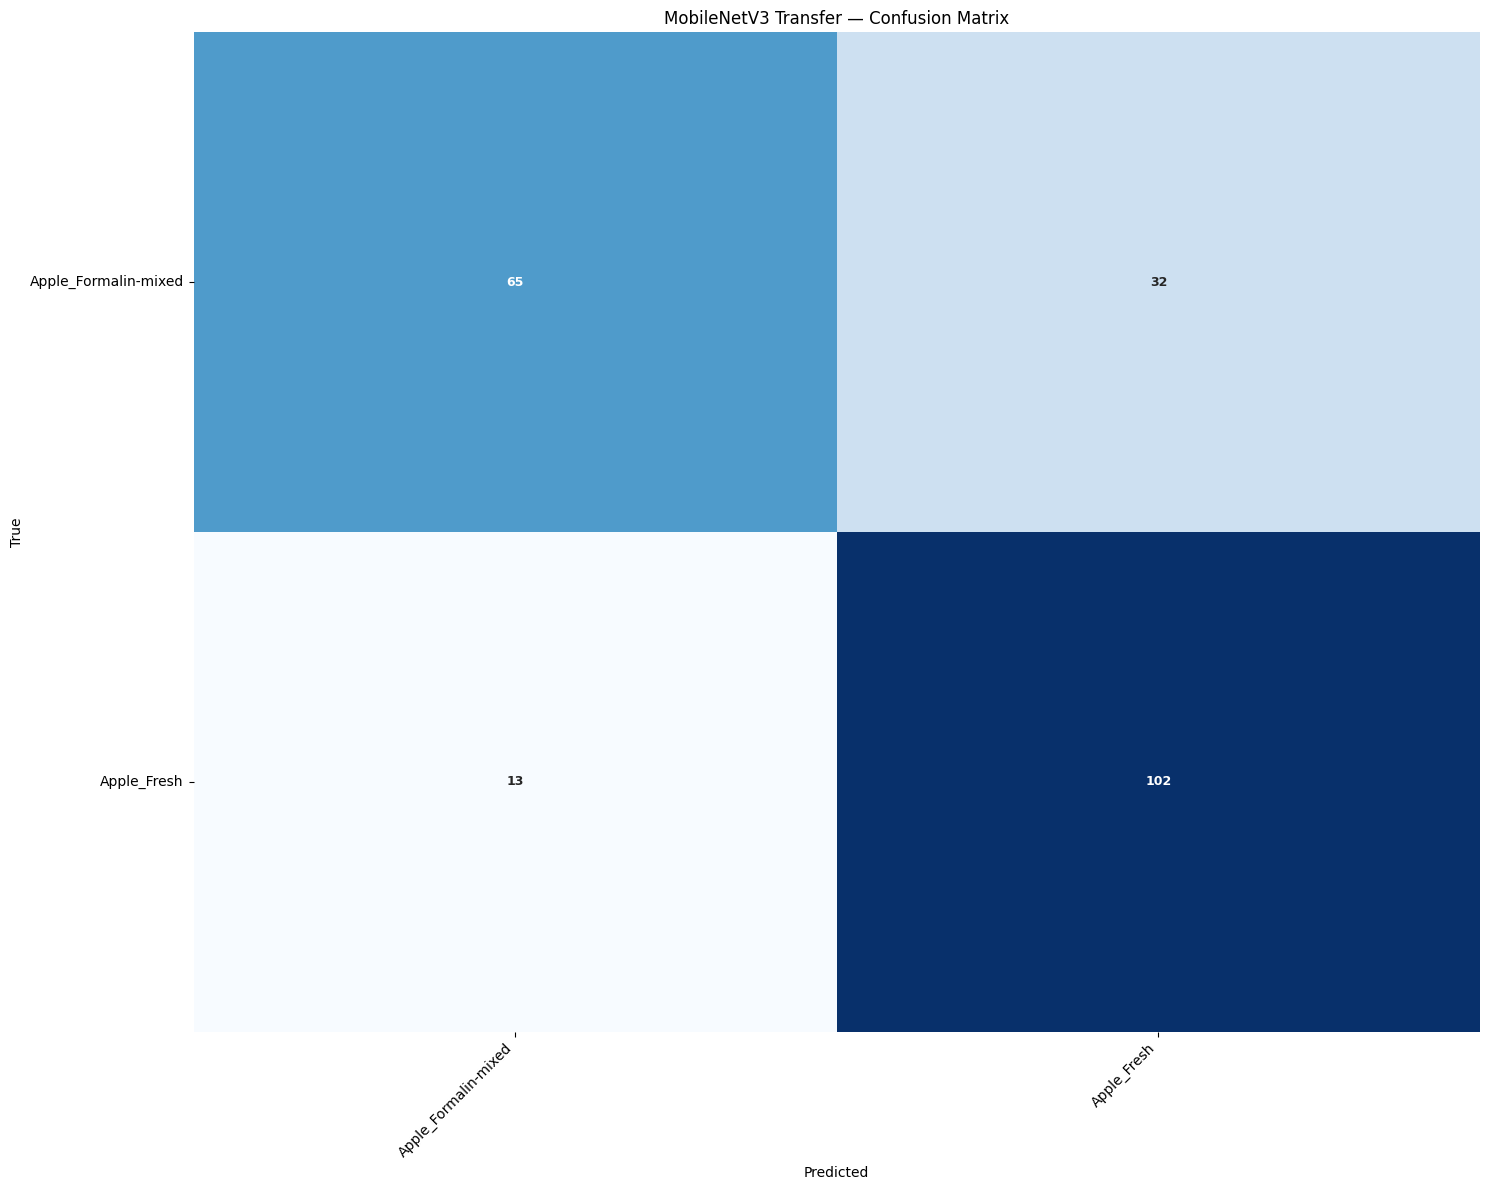

In [31]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names,
'MobileNetV3 Transfer')

In [32]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / \
{len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 157


In [33]:
FINETUNE_LR = TL_LR / 10
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [34]:
ft_history = tl_model.fit(
train_dataset, validation_data=val_dataset, epochs=20,
callbacks=make_callbacks('tl_finetuned'), verbose=2,
)

Epoch 1/20
16/16 - 12s - 775ms/step - accuracy: 0.6731 - loss: 0.7092 - val_accuracy: 0.7773 - val_loss: 0.4385 - learning_rate: 1.0000e-05
Epoch 2/20
16/16 - 1s - 64ms/step - accuracy: 0.6670 - loss: 0.6706 - val_accuracy: 0.7915 - val_loss: 0.4331 - learning_rate: 1.0000e-05
Epoch 3/20
16/16 - 1s - 32ms/step - accuracy: 0.6924 - loss: 0.6463 - val_accuracy: 0.7915 - val_loss: 0.4312 - learning_rate: 1.0000e-05
Epoch 4/20
16/16 - 0s - 30ms/step - accuracy: 0.6934 - loss: 0.6331 - val_accuracy: 0.7915 - val_loss: 0.4294 - learning_rate: 1.0000e-05
Epoch 5/20
16/16 - 1s - 32ms/step - accuracy: 0.6548 - loss: 0.6661 - val_accuracy: 0.7915 - val_loss: 0.4282 - learning_rate: 1.0000e-05
Epoch 6/20
16/16 - 0s - 31ms/step - accuracy: 0.6711 - loss: 0.6255 - val_accuracy: 0.7915 - val_loss: 0.4271 - learning_rate: 1.0000e-05
Epoch 7/20
16/16 - 1s - 32ms/step - accuracy: 0.6934 - loss: 0.6130 - val_accuracy: 0.7867 - val_loss: 0.4254 - learning_rate: 1.0000e-05
Epoch 8/20
16/16 - 1s - 44ms/ste

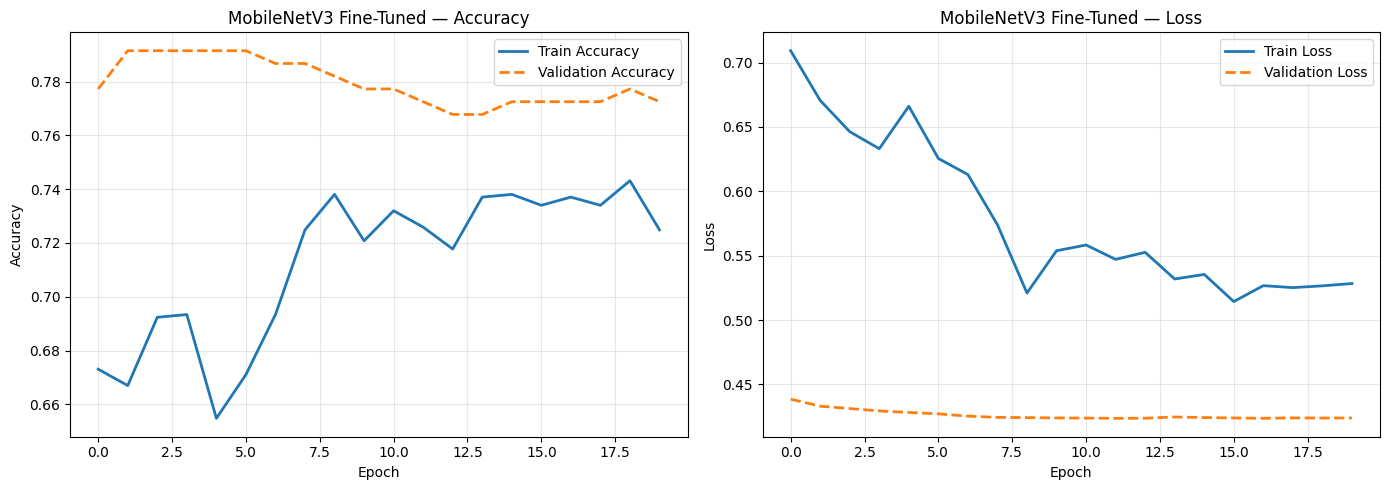

In [35]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')



MobileNetV3 Fine-Tuned
Accuracy : 0.8160
Precision : 0.8158
Recall : 0.8160
F1-Score : 0.8158

Classification Report:
                      precision    recall  f1-score   support

Apple_Formalin-mixed     0.8085    0.7835    0.7958        97
         Apple_Fresh     0.8220    0.8435    0.8326       115

            accuracy                         0.8160       212
           macro avg     0.8153    0.8135    0.8142       212
        weighted avg     0.8158    0.8160    0.8158       212



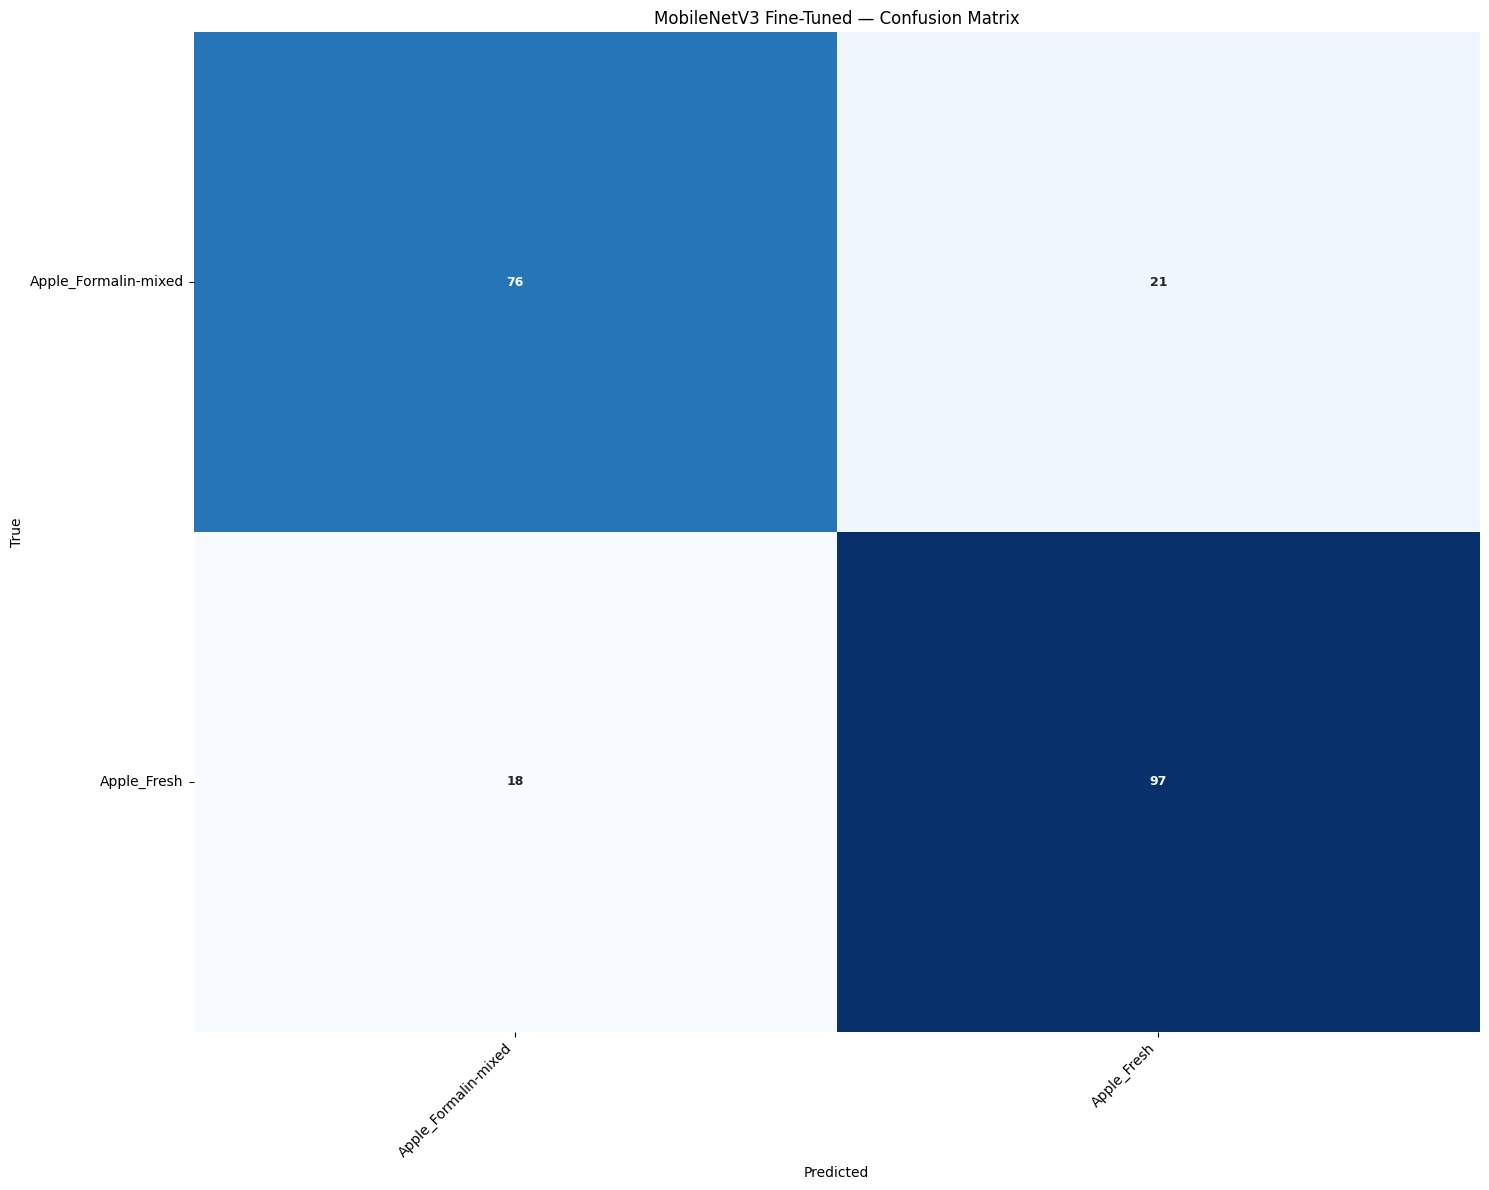

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.4575        322,338
MobileNetV3 (TL)              0.7877      1,087,346
MobileNetV3 (FT)              0.8160      1,087,346


In [38]:
ft_test_acc = evaluate_model(tl_model,
test_dataset, class_names, 'MobileNetV3 Fine-Tuned')
# STEP 35: Side-by-side model comparison. Compare all three models on validation accuracy and
# parameter count.
results = {
'Custom CNN': {'acc': cnn_test_acc, 'params': cnn_model.count_params()},
'MobileNetV3 (TL)': {'acc': tl_test_acc, 'params':
tl_model.count_params()}, 'MobileNetV3 (FT)': {'acc': ft_test_acc,
'params': tl_model.count_params()},}
print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

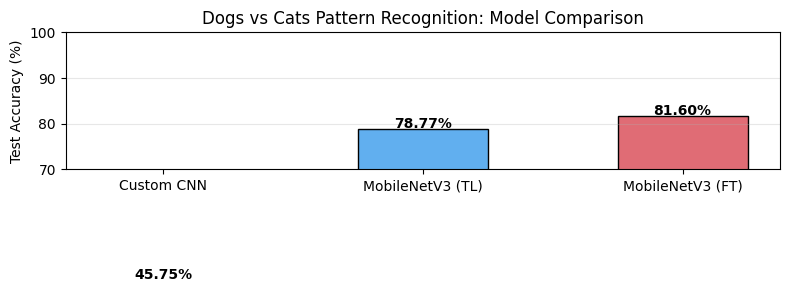

In [40]:
labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Dogs vs Cats Pattern Recognition: Model Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
    bar.get_height() + 0.3,
    f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [41]:
def predict_image(img_path, models_dict, class_names, image_size=(224,
224)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img) # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob >= 0.5)]
        print(f'{name:<25}: {label} (p={prob:.4f})')

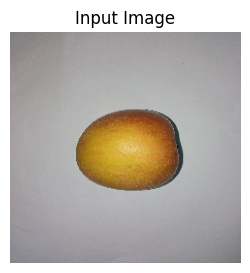


Predictions for: /content/extracted_applecontent/Apple/Fresh/msg5170347760-66136.jpg
----------------------------------------


Custom CNN               : Apple_Fresh (p=0.5648)
MobileNetV3 TL           : Apple_Formalin-mixed (p=0.4514)


In [43]:
# Update path to an image you want to test
predict_image(
    test_files[0], # Using the first image from the test set as an example
    {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
    class_names
)

In [44]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.keras')
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print(' models/custom_cnn.keras')
print(' models/mobilenetv3_transfer.keras')

Models saved:
 models/custom_cnn.keras
 models/mobilenetv3_transfer.keras
